In [1]:
import numpy as np
import matplotlib.pyplot as plt

<div style="font-size: 0.85em; line-height: 1.2;">

### 2. SVM Classification Model

#### 2.1 Mathematical Formulas

Linear classification function of SVM:

$$f(x) = w^T x + b$$

Where:

* **$w$**: weight vector
* **$b$**: bias

Classification rule:

$$\hat{y} = \text{sign}(w^T x + b)$$

If $w^T x + b > 0$, predict as **+1** If $w^T x + b < 0$, predict as **-1**

</div>

In [2]:
def predict(X, w, b):
    scores = X @ w + b
    return np.where(scores >= 0, 1, -1)

<div style="font-size: 0.85em; line-height: 1.1;">

### 3. Why Examine $yf(x)$

To handle positive and negative classes uniformly, we define:

$$z = y(w^T x + b)$$

**Meanings:**

| $z$ Value | Meaning |
| --- | --- |
| $z > 0$ | Correct classification |
| $z < 0$ | Incorrect classification |
| The larger $z$ is | Farther from the boundary |

</div>

---

<div style="font-size: 0.85em; line-height: 1.1;">

### 4. Hinge Loss

#### 4.1 Single Sample Loss Formula (单样本损失公式)

SVM uses hinge loss (SVM 使用 hinge loss):

$$L_i = \max(0, 1 - y_i(w^T x_i + b))$$

**Explanation (解释):**

| Condition (情况) | Meaning (含义) |
| --- | --- |
| $yf(x) \geq 1$ | Correct classification, far from boundary (分类正确且离边界远) |
| $0 < yf(x) < 1$ | Correct classification, but too close to boundary (分类正确但离边界太近) |
| $yf(x) \leq 0$ | Incorrect classification (分类错误) |

</div>


In [ ]:
def hinge_loss(x, y, w, b):
    score = np.dot(w, x) + b # f(x) 
    return max(0, 1 - y * score)

<div style="font-size: 0.85em; line-height: 1.1;">

### 5. SVM Total Loss Function

#### 5.1 Mathematical Formula

SVM objective function:

$$J(w, b) = \frac{1}{2} ||w||^2 + C \sum_{i=1}^{n} \max(0, 1 - y_i(w^T x_i + b))$$

It consists of two parts:

**1. Regularization Term**

$$\frac{1}{2} ||w||^2$$

**Purpose:**

* Prevents overfitting
* Equivalent to maximizing the margin

---

**2. Hinge Loss**

$$\max(0, 1 - y_i(w^T x_i + b))$$

**Purpose:**

* Penalizes misclassified samples
* Penalizes samples that fall within the margin

</div>

In [4]:
def total_loss(X, y, w, b, C=1.0):

    reg = 0.5 * np.dot(w, w)

    loss_sum = 0
    for i in range(len(X)):
        loss_sum += hinge_loss(X[i], y[i], w, b)

    return reg + C * loss_sum

<div style="font-size: 0.85em; line-height: 1.1;">

### 6. SVM Gradient Derivation

We first define:

$$z_i = y_i(w^T x_i + b)$$

Loss:

$$L_i = \max(0, 1 - z_i)$$

---

### 7. Gradient Analysis

**Case 1: If**

$$z_i \geq 1$$

**Description:**

* Correct classification
* Outside the margin

**In this case:**

$$\frac{\partial L_i}{\partial w} = 0$$

$$\frac{\partial L_i}{\partial b} = 0$$

</div>

---

<div style="font-size: 0.85em; line-height: 0.9;">

**Case 2: If**

$$z_i < 1$$

**Description:**

* Inside the margin
* Or misclassified

**In this case:**

$$L_i = 1 - y_i(w^T x_i + b)$$

**Gradient:**

$$\frac{\partial L_i}{\partial w} = -y_i x_i$$

$$\frac{\partial L_i}{\partial b} = -y_i$$

---

### 8. Gradient of Total Objective Function

**Objective function:**

$$J(w, b) = \frac{1}{2} ||w||^2 + C \sum L_i$$

</div>
<div style="font-size: 0.85em; line-height: 1.1;">

Gradient with respect to $w$:

$$\frac{\partial J}{\partial w} = w - C \sum_{i:z_i < 1} y_i x_i$$

Gradient with respect to $b$:

$$\frac{\partial J}{\partial b} = -C \sum_{i:z_i < 1} y_i$$

### 9. Gradient Descent Update Formula

Learning rate:

$$\eta$$

Update:

$$w = w - \eta \frac{\partial J}{\partial w}$$

$$b = b - \eta \frac{\partial J}{\partial b}$$

</div>



In [5]:
def train_svm(X, y, lr=0.001, C=1.0, epochs=3000):

    n_features = X.shape[1]

    w = np.zeros(n_features)
    b = 0

    loss_history = []

    for epoch in range(epochs):

        for i in range(len(X)):

            x_i = X[i]
            y_i = y[i]

            score = np.dot(w, x_i) + b
            margin = y_i * score

            if margin >= 1:
                dw = w
                db = 0

            else:
                dw = w - C * y_i * x_i
                db = -C * y_i

            w -= lr * dw
            b -= lr * db

        loss_history.append(total_loss(X, y, w, b, C))

    return w, b, loss_history

In [11]:
import data_set
X, y = data_set.generate_svm_data(seed=None)

In [12]:
w, b, loss_history = train_svm(X, y)

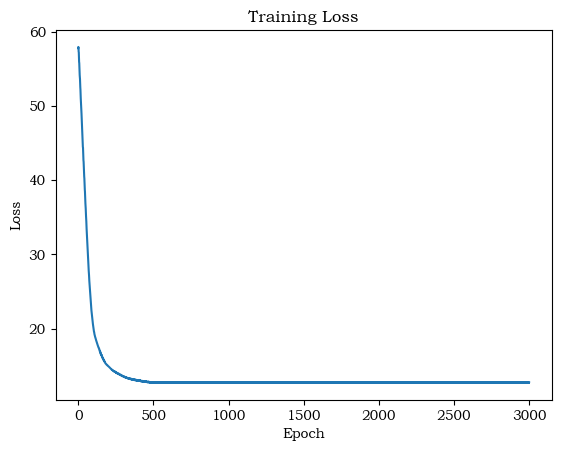

In [13]:
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

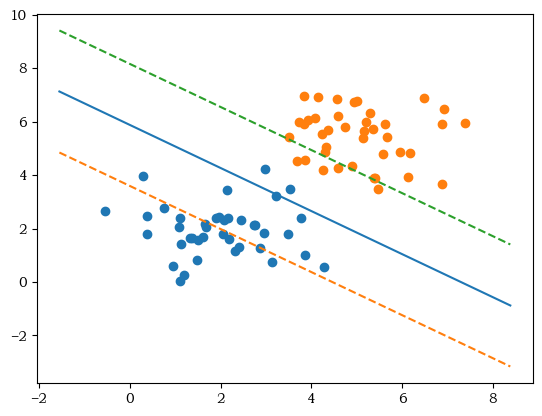

In [10]:
def plot_decision_boundary(X, y, w, b):

    plt.scatter(X[y==1][:,0], X[y==1][:,1])
    plt.scatter(X[y==-1][:,0], X[y==-1][:,1])

    x_vals = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200)

    y_decision = -(w[0]*x_vals + b)/w[1]
    y_margin1 = -(w[0]*x_vals + b -1)/w[1]
    y_margin2 = -(w[0]*x_vals + b +1)/w[1]

    plt.plot(x_vals, y_decision)
    plt.plot(x_vals, y_margin1,'--')
    plt.plot(x_vals, y_margin2,'--')

    plt.show()

plot_decision_boundary(X,y,w,b)